# Previsão da temperatura da água do mar — dataset CalCOFI

**Disciplina:** Machine Learning · **Tipo de problema:** Regressão
**Dataset:** [CalCOFI — Over 60 years of oceanographic data](https://www.kaggle.com/datasets/sohier/calcofi) (Kaggle, arquivos `bottle.csv` e `cast.csv`)

## 1. Objetivo

O CalCOFI (*California Cooperative Oceanic Fisheries Investigations*) mede o oceano na costa da Califórnia desde 1949.
Um navio para numa **estação** (um ponto no mar), desce uma garrafa de coleta e mede a água em várias **profundidades**:
temperatura, salinidade, oxigênio, nutrientes etc.

A pergunta proposta para esta base é:

> **Dá para prever a temperatura da água a partir da salinidade?**

Vamos responder a essa pergunta e depois ir além: descobrir **quais outras medições** ajudam a prever a temperatura
e qual modelo faz isso melhor.

### Como vamos medir se o modelo é bom: R² e R² ajustado

- **R² (coeficiente de determinação):** mede a fração da variação da temperatura que o modelo consegue explicar.
  R² = 0 significa que o modelo não é melhor do que chutar sempre a média; R² = 1 significa que ele acerta tudo.

  $$R^2 = 1 - \frac{\sum (y_i - \hat y_i)^2}{\sum (y_i - \bar y)^2} = 1 - \frac{\text{erro do modelo}}{\text{erro de chutar a média}}$$

- **R² ajustado:** o R² comum **nunca diminui** quando colocamos mais variáveis, mesmo que sejam inúteis.
  O R² ajustado corrige isso e **penaliza** cada variável extra. Por isso ele é a métrica certa para
  **comparar modelos com números diferentes de variáveis**:

  $$R^2_{aj} = 1 - (1 - R^2)\,\frac{n - 1}{n - p - 1}$$

  em que $n$ é o número de observações e $p$ o número de variáveis.

- Também mostramos o **MAE** (erro absoluto médio, em °C), que é fácil de entender: "em média o modelo erra X graus".

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

SEED = 42  # semente fixa: o resultado é o mesmo toda vez que o notebook roda
AZUL, LARANJA, CINZA = "#2563eb", "#ea580c", "#9ca3af"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
FIGURAS = Path("figuras")
FIGURAS.mkdir(exist_ok=True)

## 2. Carga dos dados

O dataset tem dois arquivos que se complementam:

| Arquivo | Uma linha é… | O que tem |
|---|---|---|
| `bottle.csv` | uma **medição** (uma profundidade numa estação) | temperatura, salinidade, oxigênio, nutrientes… |
| `cast.csv` | uma **estação** (a parada do navio) | data, latitude, longitude, profundidade do fundo… |

Os dois se ligam pela coluna `Cst_Cnt` (o número da estação). Os arquivos devem estar em `data/`;
se não estiverem, a célula baixa do Kaggle com `kagglehub`.

In [2]:
PASTA = Path("data")
if not (PASTA / "bottle.csv").exists():
    import kagglehub, shutil
    origem = Path(kagglehub.dataset_download("sohier/calcofi"))
    PASTA.mkdir(exist_ok=True)
    for arquivo in ["bottle.csv", "cast.csv"]:
        shutil.copy(origem / arquivo, PASTA / arquivo)

bottle = pd.read_csv(PASTA / "bottle.csv", encoding="latin1", low_memory=False)
cast = pd.read_csv(PASTA / "cast.csv", encoding="latin1", low_memory=False)
print(f"bottle.csv: {bottle.shape[0]:,} linhas x {bottle.shape[1]} colunas")
print(f"cast.csv:   {cast.shape[0]:,} linhas x {cast.shape[1]} colunas")

bottle.csv: 864,863 linhas x 74 colunas
cast.csv:   34,404 linhas x 61 colunas


Do `cast.csv` trazemos só as informações da estação que podem ajudar a explicar a temperatura:
**ano, mês, latitude, longitude, profundidade do fundo e distância da costa**.

In [3]:
INFO_ESTACAO = ["Cst_Cnt", "Year", "Month", "Lat_Dec", "Lon_Dec", "Bottom_D", "Distance"]
df_completo = bottle.merge(cast[INFO_ESTACAO], on="Cst_Cnt", how="left")
print(f"Base unida: {df_completo.shape[0]:,} linhas x {df_completo.shape[1]} colunas")
df_completo[["Cst_Cnt", "Year", "Depthm", "T_degC", "Salnty", "O2ml_L", "NO3uM", "Lat_Dec", "Lon_Dec"]].head()

Base unida: 864,863 linhas x 80 colunas


,Cst_Cnt,Year,Depthm,T_degC,Salnty,O2ml_L,NO3uM,Lat_Dec,Lon_Dec
0,1,1949,0,10.50,33.440,NaN,NaN,38.833333,-124.083333
1,1,1949,8,10.46,33.440,NaN,NaN,38.833333,-124.083333
2,1,1949,10,10.46,33.437,NaN,NaN,38.833333,-124.083333
3,1,1949,19,10.45,33.420,NaN,NaN,38.833333,-124.083333
4,1,1949,20,10.45,33.421,NaN,NaN,38.833333,-124.083333


## 3. Recorte do período: 2005 a 2016

A base completa tem **mais de 860 mil medições, de 1949 a 2016**. Usamos apenas o período **2005–2016**, por três motivos:

1. **Medições completas.** Nas décadas antigas os nutrientes (fosfato, nitrato, silicato) quase nunca eram medidos.
   A célula abaixo mostra isso: antes de 2005, a maioria das linhas não tem nutrientes e seria descartada na limpeza de qualquer jeito.
2. **Coerência.** O oceano esquentou ao longo de 70 anos e os instrumentos mudaram. Misturar 1950 com 2016 seria juntar
   "dois oceanos" medidos de formas diferentes. Um período recente deixa o modelo coerente com o presente.
3. **Tamanho e tempo de execução.** Com ~97 mil medições o notebook roda em poucos minutos, sem perder a qualidade do modelo.

Importante: isto **não é uma amostra aleatória**. É uma decisão de escopo: usamos **todas** as medições do período escolhido.

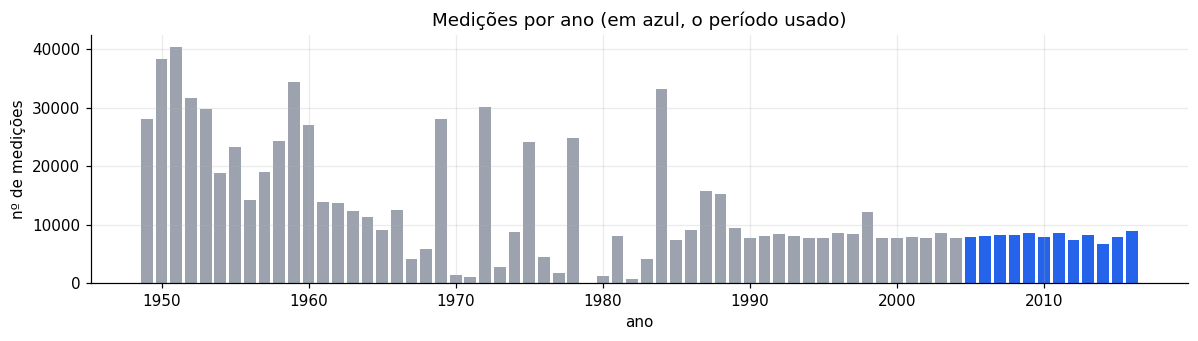

Linhas com os 4 nutrientes medidos — antes de 2005: 31% | 2005 em diante: 92%

Período 2005-2016: 96,655 medições em 3,682 estações, 80 colunas


In [4]:
NUTRIENTES = ["PO4uM", "SiO3uM", "NO3uM", "NO2uM"]
com_nutrientes = df_completo[NUTRIENTES].notna().all(axis=1)

por_ano = df_completo.groupby("Year").size()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(por_ano.index, por_ano.values, color=[AZUL if a >= 2005 else CINZA for a in por_ano.index], width=0.8)
ax.set(title="Medições por ano (em azul, o período usado)", xlabel="ano", ylabel="nº de medições")
plt.tight_layout(); plt.show()

antes = df_completo["Year"] < 2005
print(f"Linhas com os 4 nutrientes medidos — antes de 2005: {com_nutrientes[antes].mean():.0%} | 2005 em diante: {com_nutrientes[~antes].mean():.0%}")

df = df_completo[df_completo["Year"] >= 2005].copy()
print(f"\nPeríodo 2005-2016: {len(df):,} medições em {df['Cst_Cnt'].nunique():,} estações, {df.shape[1]} colunas")

## 4. Conhecendo as colunas

São mais de 80 colunas, mas elas se dividem em poucos grupos. Entender esses grupos é o que permite limpar a base com critério:

| Grupo | Exemplos | O que fazer |
|---|---|---|
| **Medições da água** | `T_degC` (temperatura), `Salnty`, `O2ml_L`, `Depthm`, nutrientes | São as candidatas a variáveis do modelo |
| **Informações da estação** | `Year`, `Month`, `Lat_Dec`, `Lon_Dec`, `Bottom_D`, `Distance` | Candidatas também |
| **Identificadores** | `Cst_Cnt`, `Btl_Cnt`, `Sta_ID`, `Depth_ID` | São só "números de RG" da linha: não têm significado físico |
| **Qualidade / precisão** | `T_qual`, `S_prec`, `O2Satq`, `PO4q`… | Notas sobre a medição, não a medição em si |
| **Valores "reportados" (`R_…`)** | `R_SALINITY`, `R_O2`, `R_PO4`… | Cópias das medições acima, já arredondadas |
| **Calculadas a partir da temperatura** | `R_TEMP`, `R_POTEMP`, `STheta`, `R_SIGMA`, `O2Sat`… | **Vazamento de dados** — explicado na seção 6 |

A tabela abaixo mostra o percentual de valores ausentes de cada coluna.

In [5]:
ausentes = (df.isna().mean() * 100).round(1).sort_values()
print("Colunas com menos de 30% de ausentes:", (ausentes < 30).sum())
print("Colunas com 30% ou mais de ausentes:", (ausentes >= 30).sum())
ausentes.to_frame("% ausentes").T

Colunas com menos de 30% de ausentes: 42
Colunas com 30% ou mais de ausentes: 38


,Cst_Cnt,R_TEMP,R_POTEMP,R_SALINITY,R_SVA,S_prec,R_DYNHT,T_prec,RecInd,R_Depth,R_PRES,Month,Lat_Dec,Lon_Dec,Salnty,T_degC,Depthm,Depth_ID,Sta_ID,Btl_Cnt,Year,R_SIGMA,Bottom_D,Distance,STheta,R_O2,R_O2Sat,O2ml_L,Oxy_Âµmol/Kg,O2Sat,C14A1q,C14A2q,R_SIO3,R_NO3,NO3uM,SiO3uM,R_PO4,PO4uM,NO2uM,R_NO2,DarkAq,MeanAq,R_SAMP,R_PHAEO,R_CHLA,ChlorA,Phaeop,NH3uM,R_NH4,BtlNum,NH3q,Chlqua,Phaqua,S_qual,O_qual,P_qual,O2Satq,SThtaq,T_qual,NO2q,NO3q,PO4q,SiO3qu,MeanAs,DarkAs,IncTim,C14As2,C14As1,MeanAp,DarkAp,C14A2p,C14A1p,LightP,TA1,DIC1,TA2,DIC2,DIC Quality Comment,pH1,pH2
% ausentes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,1.1,3.0,3.0,3.0,3.1,3.1,7.0,7.0,7.5,7.5,7.5,7.5,7.7,7.7,7.8,7.8,9.1,9.1,30.0,32.7,32.7,32.7,32.8,32.8,32.8,33.5,58.5,67.8,67.8,73.9,82.0,83.0,85.0,87.6,88.2,90.0,90.2,92.3,92.5,92.7,92.7,94.9,94.9,94.9,95.0,95.0,96.7,96.7,96.9,97.8,97.9,99.8,99.8,99.9,99.9,100.0


## 5. Variável-alvo: a temperatura (`T_degC`)

A temperatura é o alvo natural: é a pergunta da base, quase não tem valores ausentes e é uma grandeza contínua (problema de **regressão**).

Antes de modelar, vemos quanto cada medição se relaciona com ela. Usamos a correlação de **Spearman**, que mede
se duas variáveis "sobem e descem juntas" mesmo quando a relação não é uma reta, e é robusta a outliers.

In [6]:
MEDICOES = ["T_degC", "Salnty", "Depthm", "O2ml_L", "PO4uM", "SiO3uM", "NO3uM", "NO2uM", "Lat_Dec", "Lon_Dec", "Bottom_D", "Distance", "Month", "Year"]
correlacao = df[MEDICOES].corr(method="spearman")["T_degC"].drop("T_degC").sort_values(key=abs, ascending=False)
correlacao.round(2).to_frame("Spearman com T_degC")

,Spearman com T_degC
NO3uM,-0.98
SiO3uM,-0.97
PO4uM,-0.97
Depthm,-0.93
O2ml_L,0.91
Salnty,-0.85
NO2uM,0.30
Lat_Dec,-0.06
Bottom_D,-0.06
Month,0.05


**Interpretação.**

- **Profundidade, nutrientes e oxigênio** têm correlação muito forte com a temperatura (|ρ| > 0,9). Faz sentido físico:
  - quanto mais **fundo**, mais **fria** a água (o sol só aquece a superfície);
  - a água fria e funda é rica em **nutrientes** (nitrato, fosfato, silicato) porque lá embaixo não há algas para consumi-los;
  - a água quente da superfície tem mais **oxigênio**, que vem do contato com o ar e da fotossíntese das algas.
- A **salinidade** também é forte (ρ ≈ −0,85): as águas profundas da Califórnia são mais salgadas que as da superfície.
- **Localização e data** quase não se relacionam com a temperatura *sozinhas*, mas podem ajudar combinadas com as outras.

## 6. Limpeza dos dados

### 6.1 Quais colunas saem e por quê

Removemos colunas em quatro categorias:

1. **Identificadores** (`Cst_Cnt`, `Btl_Cnt`, `Sta_ID`…): são códigos, não informação física.
   (`Cst_Cnt` é guardado à parte porque será usado para dividir treino e teste — seção 8.)
2. **Qualidade e precisão** (`*_qual`, `*_prec`, `*q`…): descrevem a medição, não a água.
3. **Cópias e colunas com 30% ou mais de ausentes**: as colunas `R_…` repetem medições que já temos;
   clorofila e amônia (`ChlorA`, `Phaeop`, `NH3uM`) faltam em ~1/3 das linhas — mantê-las obrigaria a jogar fora
   1/3 da base.
4. **Vazamento de dados (*data leakage*).** Algumas colunas são **calculadas a partir da própria temperatura**:

| Coluna | O que é | Por que é vazamento |
|---|---|---|
| `R_TEMP`, `R_POTEMP` | Temperatura reportada / temperatura potencial | É a própria resposta |
| `STheta`, `R_SIGMA` | Densidade da água | Calculada com temperatura **e** salinidade |
| `R_SVA`, `R_DYNHT` | Anomalia de volume e altura dinâmica | Calculadas a partir da densidade |
| `O2Sat`, `R_O2Sat` | Saturação de oxigênio (%) | O oxigênio "máximo" depende da temperatura |
| `Oxy_µmol/Kg` | Oxigênio em outra unidade | A conversão usa a densidade |

Usar essas colunas seria como **dar a resposta da prova ao aluno**: o R² ficaria quase 1, mas o modelo seria inútil,
porque na prática quem tem essas colunas já tem a temperatura. A célula abaixo mostra isso acontecendo.

In [7]:
# Demonstração: o mesmo modelo, com e sem a coluna que "vaza" a temperatura
amostra = df[["T_degC", "Salnty", "STheta"]].dropna().sample(frac=1, random_state=SEED)
metade = len(amostra) // 2
treino_demo, teste_demo = amostra.iloc[:metade], amostra.iloc[metade:]
for colunas in (["Salnty"], ["Salnty", "STheta"]):
    demo = HistGradientBoostingRegressor(random_state=SEED).fit(treino_demo[colunas], treino_demo["T_degC"])
    print(f"R² com {colunas}: {demo.score(teste_demo[colunas], teste_demo['T_degC']):.3f}")
print(f"\nCorrelação entre T_degC e R_TEMP: {df['T_degC'].corr(df['R_TEMP']):.4f}  (é a mesma coluna)")

R² com ['Salnty']: 0.695


R² com ['Salnty', 'STheta']: 0.999

Correlação entre T_degC e R_TEMP: 1.0000  (é a mesma coluna)


Só a salinidade dá R² ≈ 0,70; colocando a densidade (`STheta`) o R² vai para **0,999**. Não é porque o modelo ficou
genial: é porque a densidade é calculada **com** a temperatura — o modelo só está "desfazendo a conta".
Por isso essas colunas saem.

In [8]:
ALVO = "T_degC"
PREDITORAS = [
    "Salnty", "Depthm", "O2ml_L",                    # medições físicas
    "PO4uM", "SiO3uM", "NO3uM", "NO2uM",             # nutrientes
    "Lat_Dec", "Lon_Dec", "Bottom_D", "Distance",    # localização da estação
    "Month", "Year",                                 # data
]
VAZAMENTO = ["R_TEMP", "R_POTEMP", "STheta", "R_SIGMA", "R_SVA", "R_DYNHT", "O2Sat", "R_O2Sat"] + [c for c in df.columns if c.startswith("Oxy")]

removidas = [c for c in df.columns if c not in PREDITORAS + [ALVO]]
print(f"Colunas antes: {df.shape[1]} | removidas: {len(removidas)} | ficaram: {len(PREDITORAS)} preditoras + o alvo")
print(f"\nDessas, removidas por vazamento: {VAZAMENTO}")

Colunas antes: 80 | removidas: 66 | ficaram: 13 preditoras + o alvo

Dessas, removidas por vazamento: ['R_TEMP', 'R_POTEMP', 'STheta', 'R_SIGMA', 'R_SVA', 'R_DYNHT', 'O2Sat', 'R_O2Sat', 'Oxy_Âµmol/Kg']


### 6.2 Quais linhas saem e por quê

| Etapa | Motivo |
|---|---|
| **Duplicatas** | Uma medição repetida poderia cair no treino e no teste ao mesmo tempo: o modelo "veria a resposta" (vazamento) |
| **Valores ausentes** | Não dá para inventar a temperatura (é o alvo), e preencher nutrientes com médias criaria valores falsos |
| **Outliers** (abaixo de 0,1% ou acima de 99,9%) | Erros de registro: por exemplo, nitrato negativo (impossível) |

In [9]:
dados = df[["Cst_Cnt", ALVO] + PREDITORAS]
print(f"Início:                  {len(dados):,}")

dados = dados.drop_duplicates(subset=[ALVO] + PREDITORAS)
print(f"Após remover duplicatas: {len(dados):,}")

dados = dados.dropna()
print(f"Após remover ausentes:   {len(dados):,}")

MEDIDAS = [ALVO, "Salnty", "Depthm", "O2ml_L", "PO4uM", "SiO3uM", "NO3uM", "NO2uM"]
minimos, maximos = dados[MEDIDAS].quantile(0.001), dados[MEDIDAS].quantile(0.999)
dados = dados[((dados[MEDIDAS] >= minimos) & (dados[MEDIDAS] <= maximos)).all(axis=1)]
print(f"Após remover outliers:   {len(dados):,}  ({dados['Cst_Cnt'].nunique():,} estações)")

Início:                  96,655
Após remover duplicatas: 96,634
Após remover ausentes:   88,773
Após remover outliers:   88,143  (3,490 estações)


## 7. Análise exploratória

### 7.1 A temperatura em função de cada medição

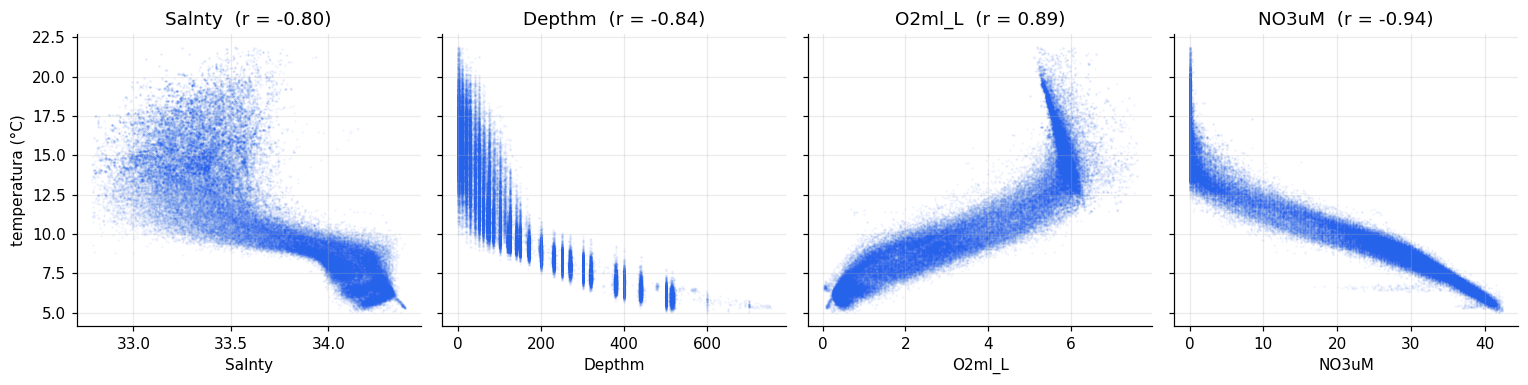

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, col in zip(axes, ["Salnty", "Depthm", "O2ml_L", "NO3uM"]):
    ax.scatter(dados[col], dados[ALVO], s=2, alpha=0.08, color=AZUL, linewidths=0)
    ax.set(title=f"{col}  (r = {dados[col].corr(dados[ALVO]):.2f})", xlabel=col)
axes[0].set_ylabel("temperatura (°C)")
plt.tight_layout(); plt.savefig(FIGURAS / "dispersao_variaveis.png", bbox_inches="tight"); plt.show()

**Interpretação.**

- **Salinidade:** existe relação (água mais salgada tende a ser mais fria), mas a nuvem é larga — para a mesma salinidade
  há temperaturas muito diferentes. Isso já indica que **só a salinidade não vai bastar**.
- **Profundidade:** a temperatura cai rápido nos primeiros ~200 m e depois quase não muda. É uma **curva, não uma reta**
  (a *termoclina*). Uma regressão linear vai ter dificuldade aqui; um modelo não linear deve se sair melhor.
- **Oxigênio e nitrato:** relações fortes e bem "apertadas" — boas candidatas a variáveis importantes.

### 7.2 Multicolinearidade (VIF)

Várias preditoras medem "a mesma coisa" (todos os nutrientes sobem juntos com a profundidade). Isso se chama
**multicolinearidade** e é medido pelo **VIF** (*Variance Inflation Factor*): quanto da variância de um coeficiente é
"inflada" porque a variável pode ser prevista pelas outras. Regra prática: **VIF > 10 indica problema**.

In [11]:
X_vif = sm.add_constant(dados[PREDITORAS])
vif = pd.Series([variance_inflation_factor(X_vif.values, i + 1) for i in range(len(PREDITORAS))], index=PREDITORAS)
vif.sort_values(ascending=False).round(1).to_frame("VIF")

,VIF
PO4uM,188.5
NO3uM,112.0
Distance,75.9
SiO3uM,48.8
O2ml_L,48.0
Lat_Dec,34.8
Lon_Dec,30.8
Depthm,22.8
Salnty,9.7
Bottom_D,4.5


**Interpretação.** Os nutrientes (`PO4uM`, `NO3uM`, `SiO3uM`), o oxigênio e as variáveis de localização
(`Distance`, `Lat_Dec`, `Lon_Dec` — a distância da costa é calculada a partir da posição) têm VIF muito acima de 10: eles carregam
quase a mesma informação. Isso **não atrapalha a previsão**, mas deixa os coeficientes da regressão linear instáveis e
difíceis de interpretar. É um bom motivo para tentar **reduzir o número de variáveis** mais adiante.

## 8. Modelagem

Testamos **seis modelos, um de cada vez, do mais simples ao mais completo**. Cada um responde a uma pergunta,
e a resposta leva ao próximo:

| Modelo | Variáveis | Pergunta |
|---|---|---|
| 1. Regressão linear | salinidade | Dá para prever a temperatura só pela salinidade? (pergunta da base) |
| 2. Regressão linear | salinidade + profundidade | Quanto a profundidade acrescenta? |
| 3. Regressão linear | todas as 13 | Usando tudo o que temos, até onde vai um modelo linear? |
| — Seleção (Lasso) | 13 → ranking | Quais variáveis realmente importam? |
| 4. Regressão linear reduzida | 6 | Dá para simplificar sem perder muito? |
| 5. Gradient Boosting reduzido | 6 | Um modelo não linear faz melhor com as mesmas variáveis? |
| 6. Gradient Boosting | todas as 13 | Qual o melhor resultado possível com estes dados? |

### 8.1 Divisão treino/teste — por estação

- **80% treino / 20% teste**, com `random_state=42`. O teste fica guardado e só é usado para avaliar.
- **Detalhe importante:** numa mesma estação, medições em profundidades vizinhas (ex.: 50 m e 60 m) são quase iguais.
  Se uma fosse para o treino e a outra para o teste, o modelo "colaria" do vizinho e o R² ficaria inflado.
  Por isso dividimos **por estação** (`GroupShuffleSplit`): todas as medições de uma estação ficam do mesmo lado.
- **Validação cruzada de 5 partes** (`GroupKFold`) dentro do treino, também por estação: o treino é dividido em 5 partes,
  o modelo treina em 4 e é avaliado na 5ª, cinco vezes. Isso mostra se o resultado é estável ou foi sorte.

In [12]:
X, y, grupos = dados[PREDITORAS], dados[ALVO], dados["Cst_Cnt"]

divisor = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
i_treino, i_teste = next(divisor.split(X, y, grupos))
X_treino, X_teste = X.iloc[i_treino], X.iloc[i_teste]
y_treino, y_teste = y.iloc[i_treino], y.iloc[i_teste]
grupos_treino = grupos.iloc[i_treino]
cv = GroupKFold(n_splits=5)

print(f"Treino: {len(X_treino):,} medições ({grupos_treino.nunique():,} estações)")
print(f"Teste:  {len(X_teste):,} medições ({grupos.iloc[i_teste].nunique():,} estações)")
print(f"Estações em comum entre treino e teste: {len(set(grupos_treino) & set(grupos.iloc[i_teste]))}")


def r2_ajustado(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


resultados, previsoes, modelos, variaveis_usadas = [], {}, {}, {}


def avaliar(nome, modelo, colunas):
    # Treina no treino, mede validação cruzada e avalia no teste
    modelo.fit(X_treino[colunas], y_treino)
    pred_treino = modelo.predict(X_treino[colunas])
    pred_teste = modelo.predict(X_teste[colunas])
    r2_cv = cross_val_score(modelo, X_treino[colunas], y_treino, cv=cv, groups=grupos_treino, scoring="r2")
    r2_teste = r2_score(y_teste, pred_teste)
    linha = {
        "modelo": nome,
        "nº variáveis": len(colunas),
        "R² treino": r2_score(y_treino, pred_treino),
        "R² validação cruzada": r2_cv.mean(),
        "desvio CV": r2_cv.std(),
        "R² teste": r2_teste,
        "R² ajustado teste": r2_ajustado(r2_teste, len(y_teste), len(colunas)),
        "MAE teste (°C)": mean_absolute_error(y_teste, pred_teste),
        "RMSE teste (°C)": np.sqrt(mean_squared_error(y_teste, pred_teste)),
    }
    resultados.append(linha)
    previsoes[nome], modelos[nome], variaveis_usadas[nome] = pred_teste, modelo, list(colunas)
    return pd.DataFrame([linha]).set_index("modelo").round(4)

Treino: 70,542 medições (2,792 estações)
Teste:  17,601 medições (698 estações)
Estações em comum entre treino e teste: 0


### 8.2 Modelo 1 — Regressão linear só com salinidade

**O que é.** A regressão linear por mínimos quadrados (OLS) encontra a reta que minimiza a soma dos erros ao quadrado:

$$\text{temperatura} = \beta_0 + \beta_1 \cdot \text{salinidade} + \varepsilon$$

**Variáveis e motivo.** Só `Salnty`, porque é exatamente a pergunta proposta para esta base. É o nosso **modelo de
referência (baseline)**: todos os outros modelos precisam superá-lo.

Usamos o `statsmodels` para ver a tabela completa (coeficientes, p-valores, R²).

In [13]:
ols_m1 = sm.OLS(y_treino, sm.add_constant(X_treino[["Salnty"]])).fit()
print(ols_m1.summary().tables[1])
avaliar("1. Linear (salinidade)", LinearRegression(), ["Salnty"])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        251.9778      0.671    375.418      0.000     250.662     253.293
Salnty        -7.1491      0.020   -358.962      0.000      -7.188      -7.110


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
1. Linear (salinidade),1,0.6462,0.6462,0.0089,0.6479,0.6478,1.5759,2.1505


**Interpretação.**

- Respondendo à pergunta da base: **sim, a salinidade ajuda**, mas explica só cerca de **65%** da variação da temperatura
  (R² de teste = 0,648), com erro médio de **1,58 °C**.
- O coeficiente é negativo (−7,15 °C por unidade de salinidade): água mais salgada é, em média, mais fria — porque aqui
  a água salgada é a água profunda.
- O p-valor ≈ 0 diz que a relação é estatisticamente significativa — mas **significativa não quer dizer suficiente**:
  sobra muita variação sem explicação.

**Próximo passo.** O gráfico da seção 7 mostrou que a **profundidade** é o que mais "organiza" a temperatura. Vamos adicioná-la.

### 8.3 Modelo 2 — Regressão linear com salinidade + profundidade

**Variáveis e motivo.** `Salnty` e `Depthm`. A profundidade é o fator físico mais óbvio: o sol aquece só a superfície.

In [14]:
avaliar("2. Linear (salinidade + profundidade)", LinearRegression(), ["Salnty", "Depthm"])

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
2. Linear (salinidade + profundidade),2,0.7404,0.7403,0.0068,0.7402,0.7402,1.4298,1.847


**Interpretação.** O R² sobe para **0,740** e o erro cai para **1,43 °C**. A profundidade ajuda bastante, mas
ainda sobra muita coisa — e lembre que a relação com a profundidade é **curva**, enquanto este modelo só desenha **retas**.

**Próximo passo.** Colocar **todas** as 13 variáveis e ver até onde um modelo linear consegue chegar.

### 8.4 Modelo 3 — Regressão linear com todas as variáveis

**Variáveis e motivo.** As 13 preditoras que sobraram da limpeza. Colocamos **todas**, sem escolher à mão, para medir o
máximo que um modelo linear extrai desses dados — sem que uma escolha nossa influencie o resultado.

In [15]:
ols_m3 = sm.OLS(y_treino, sm.add_constant(X_treino[PREDITORAS])).fit()
print(ols_m3.summary().tables[1])
avaliar("3. Linear (13 variáveis)", LinearRegression(), PREDITORAS)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -73.9159      1.907    -38.763      0.000     -77.653     -70.178
Salnty         1.8494      0.021     86.186      0.000       1.807       1.891
Depthm        -0.0077   8.81e-05    -87.561      0.000      -0.008      -0.008
O2ml_L        -1.7295      0.010   -179.970      0.000      -1.748      -1.711
PO4uM         -4.9515      0.039   -127.063      0.000      -5.028      -4.875
SiO3uM         0.0656      0.001     81.892      0.000       0.064       0.067
NO3uM         -0.2182      0.002   -105.602      0.000      -0.222      -0.214
NO2uM         -1.2956      0.039    -33.547      0.000      -1.371      -1.220
Lat_Dec        0.0501      0.013      3.871      0.000       0.025       0.075
Lon_Dec        0.0435      0.008      5.531      0.000       0.028       0.059
Bottom_D   -3.754e-07   3.63e-06     -0.103      0.9

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
3. Linear (13 variáveis),13,0.958,0.9578,0.0017,0.9568,0.9567,0.5369,0.7536


**Interpretação.**

- Grande salto: R² de teste **0,957** e erro médio de **0,54 °C**. Nutrientes e oxigênio trazem a informação que
  faltava: eles "denunciam" de que camada do oceano a água veio.
- O R² de treino, o da validação cruzada e o de teste são praticamente iguais: **não há overfitting** (o modelo não decorou o treino).
- **Efeito da multicolinearidade na prática:** no Modelo 1 o coeficiente da salinidade era **−7,15**; aqui virou **+1,85**.
  O do oxigênio é **negativo**, embora mais oxigênio signifique água mais quente. Os sinais "estranhos" acontecem
  porque as variáveis carregam a mesma informação (VIF alto) e o modelo divide o efeito entre elas de forma instável.
  A **previsão** continua boa, mas os **coeficientes** deixam de ser interpretáveis individualmente.
- `Bottom_D` tem p-valor 0,92: sozinha, não acrescenta nada quando as outras já estão no modelo.

Será que precisamos de todas as 13?

**Próximo passo.** Descobrir **quais variáveis realmente importam**.

### 8.5 Seleção de variáveis com Lasso

O **Lasso** é uma regressão linear com uma **penalidade** sobre o tamanho dos coeficientes:

$$\min_\beta \; \sum (y_i - \hat y_i)^2 + \alpha \sum |\beta_j|$$

- Com $\alpha$ (alfa) muito grande, a penalidade "zera" todos os coeficientes: nenhuma variável entra.
- Diminuindo $\alpha$ aos poucos, as variáveis vão entrando **uma de cada vez, da mais útil para a menos útil**.
- Essa **ordem de entrada** vira um **ranking de importância** feito pelos próprios dados, e não por escolha nossa.

As variáveis são **padronizadas** antes (média 0, desvio 1), porque a penalidade depende da escala: sem isso,
profundidade (em metros, até centenas) e nitrito (em µmol, perto de zero) não seriam comparáveis.
A seleção usa **somente o treino**.

In [16]:
Z_treino = StandardScaler().fit_transform(X_treino)
alphas, coefs, _ = lasso_path(Z_treino, y_treino - y_treino.mean(), n_alphas=200)

# Ordem em que cada variável entra no modelo conforme alpha diminui
ordem = []
for i in range(len(alphas)):
    for j in np.flatnonzero(coefs[:, i]):
        if PREDITORAS[j] not in ordem:
            ordem.append(PREDITORAS[j])
ordem += [c for c in PREDITORAS if c not in ordem]  # variáveis que nunca entraram vão para o fim

pd.DataFrame({"posição": range(1, len(ordem) + 1), "variável": ordem}).set_index("posição").T

posição,1,2,3,4,5,6,7,8,9,10,11,12,13
variável,NO3uM,Month,NO2uM,Lon_Dec,Bottom_D,Salnty,Depthm,PO4uM,Year,O2ml_L,SiO3uM,Lat_Dec,Distance


**Quantas variáveis usar?** Treinamos os dois tipos de modelo (linear e Gradient Boosting) com as $k$ primeiras variáveis
do ranking e medimos o R² por **validação cruzada** (só no treino) para cada $k$.

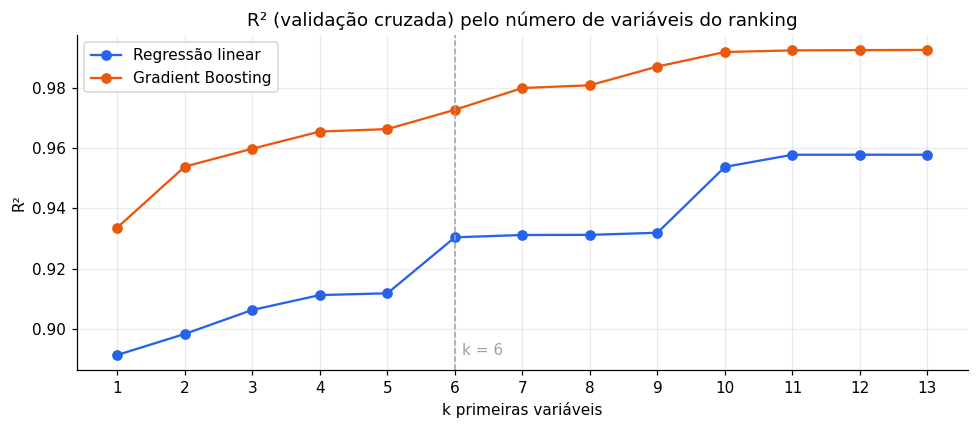

k,1,2,3,4,5,6,7,8,9,10,11,12,13
Regressão linear,0.891,0.898,0.906,0.911,0.912,0.930,0.931,0.931,0.932,0.954,0.958,0.958,0.958
Gradient Boosting,0.934,0.954,0.960,0.966,0.966,0.973,0.980,0.981,0.987,0.992,0.992,0.993,0.993


In [17]:
ks = range(1, len(PREDITORAS) + 1)
curva = []
for k in ks:
    cols = ordem[:k]
    curva.append({
        "k": k,
        "Regressão linear": cross_val_score(LinearRegression(), X_treino[cols], y_treino, cv=cv, groups=grupos_treino, scoring="r2").mean(),
        "Gradient Boosting": cross_val_score(HistGradientBoostingRegressor(random_state=SEED), X_treino[cols], y_treino, cv=cv, groups=grupos_treino, scoring="r2").mean(),
    })
curva = pd.DataFrame(curva).set_index("k")

K = 6
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curva.index, curva["Regressão linear"], "o-", color=AZUL, label="Regressão linear")
ax.plot(curva.index, curva["Gradient Boosting"], "o-", color=LARANJA, label="Gradient Boosting")
ax.axvline(K, color=CINZA, linestyle="--", linewidth=1)
ax.text(K + 0.1, curva.values.min(), f"k = {K}", color=CINZA)
ax.set(title="R² (validação cruzada) pelo número de variáveis do ranking", xlabel="k primeiras variáveis", ylabel="R²", xticks=list(ks))
ax.legend(); plt.tight_layout(); plt.savefig(FIGURAS / "curva_numero_variaveis.png", bbox_inches="tight"); plt.show()
curva.round(3).T

**Interpretação.**

- Com **1 variável só** (`NO3uM`), o R² já passa de **0,89** — muito acima da salinidade sozinha (Modelo 1).
- A curva **cresce rápido no começo e depois vai achatando**: as primeiras variáveis trazem a maior parte da informação.
- O **Gradient Boosting fica acima da regressão linear em todos os pontos**, porque captura as curvas (como a termoclina).
- Escolhemos **k = 6**: é onde a regressão linear dá um salto (0,912 → 0,930) e depois fica parada até k = 9.
  É uma versão "enxuta": menos da metade das variáveis, perdendo pouco R².
- Atenção à escala do eixo: ele começa em 0,89, então as diferenças parecem maiores do que são.

**Por que essas 6 variáveis fazem sentido:**

| # | Variável | O que representa |
|---|---|---|
| 1 | `NO3uM` (nitrato) | Sozinha "denuncia" a camada da água: muito nitrato = água funda e fria; pouco = superfície quente. Substitui a profundidade |
| 2 | `Month` (mês) | Depois que o nitrato explicou a profundidade, o que sobra é a **estação do ano**: a superfície esquenta no verão |
| 3 | `NO2uM` (nitrito) | Marca uma camada específica (logo abaixo da superfície, onde as bactérias transformam nutrientes) |
| 4 | `Lon_Dec` (longitude) | Perto da costa há **ressurgência**: água fria do fundo sobe; longe da costa a água é mais quente |
| 5 | `Bottom_D` (prof. do fundo) | Diferencia estações costeiras rasas de estações em mar aberto |
| 6 | `Salnty` (salinidade) | Distingue massas de água de origens diferentes (a pergunta da base!) |

Repare que a **profundidade não entrou no top 6**: o nitrato já carrega quase a mesma informação (são muito correlacionados),
então o Lasso escolhe só uma delas. É o VIF alto em ação.

Variáveis selecionadas:

In [18]:
SELECIONADAS = ordem[:K]
print(f"{K} variáveis selecionadas: {SELECIONADAS}")

6 variáveis selecionadas: ['NO3uM', 'Month', 'NO2uM', 'Lon_Dec', 'Bottom_D', 'Salnty']


### 8.6 Modelo 4 — Regressão linear reduzida (6 variáveis)

**Variáveis e motivo.** As 6 primeiras do ranking do Lasso — escolhidas pelos dados, não à mão.

In [19]:
ols_m4 = sm.OLS(y_treino, sm.add_constant(X_treino[SELECIONADAS])).fit()
print(ols_m4.summary().tables[1])
avaliar(f"4. Linear ({K} variáveis)", LinearRegression(), SELECIONADAS)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -96.6253      0.953   -101.412      0.000     -98.493     -94.758
NO3uM         -0.3294      0.001   -489.396      0.000      -0.331      -0.328
Month          0.0782      0.001     79.216      0.000       0.076       0.080
NO2uM         -3.5236      0.046    -76.405      0.000      -3.614      -3.433
Lon_Dec        0.0140      0.003      4.418      0.000       0.008       0.020
Bottom_D   -8.738e-06   3.97e-06     -2.202      0.028   -1.65e-05   -9.59e-07
Salnty         3.4129      0.025    137.328      0.000       3.364       3.462


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
4. Linear (6 variáveis),6,0.9306,0.9304,0.002,0.9283,0.9283,0.6773,0.9702


**Interpretação.** Com 6 variáveis a regressão linear chega a R² **0,928** (contra 0,957 com as 13), erro médio de
**0,68 °C**. Perde um pouco, mas é um modelo bem mais simples de explicar.

**Próximo passo.** A regressão linear só desenha retas. Com **as mesmas 6 variáveis**, um modelo não linear faz melhor?

### 8.7 Modelo 5 — Gradient Boosting reduzido (6 variáveis)

**O que é.** Um conjunto de **árvores de decisão construídas em sequência**: a 1ª árvore faz uma previsão grosseira,
a 2ª aprende a corrigir os erros da 1ª, a 3ª corrige os erros que sobraram, e assim por diante (100 árvores).
Cada árvore faz perguntas do tipo "a profundidade é maior que 150 m?", então o modelo consegue representar **curvas e
interações** que a regressão linear não consegue.

**Variáveis e motivo.** As **mesmas 6** do Modelo 4. Mudando só o algoritmo, a comparação é justa:
qualquer diferença vem do tipo de modelo (linear × não linear), não das variáveis.
Usamos `HistGradientBoostingRegressor` com os hiperparâmetros padrão do scikit-learn.

In [20]:
avaliar(f"5. Gradient Boosting ({K} variáveis)", HistGradientBoostingRegressor(random_state=SEED), SELECIONADAS)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
5. Gradient Boosting (6 variáveis),6,0.9783,0.9727,0.0009,0.9726,0.9726,0.3805,0.6001


**Interpretação.** Com as mesmas 6 variáveis, o R² sobe de 0,928 para **0,973** e o erro cai de 0,68 para
**0,38 °C**. Confirma o que o gráfico da profundidade sugeria: **a relação é não linear**, e um modelo que enxerga
curvas aproveita melhor as mesmas informações.

O R² de treino (0,978) é um pouco maior que o de teste — um leve **overfitting**, normal em modelos de árvores —
mas a validação cruzada (0,973) coincide com o teste e confirma o desempenho real.

**Próximo passo.** E se o Gradient Boosting usar todas as 13 variáveis?

### 8.8 Modelo 6 — Gradient Boosting com todas as variáveis

**Variáveis e motivo.** As 13. Serve para medir o **teto** do que estes dados permitem e ver se as 7 variáveis
extras compensam.

In [21]:
avaliar("6. Gradient Boosting (13 variáveis)", HistGradientBoostingRegressor(random_state=SEED), PREDITORAS)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
6. Gradient Boosting (13 variáveis),13,0.9944,0.9926,0.0003,0.9927,0.9927,0.1995,0.3087


**Interpretação.** É o melhor modelo do trabalho: R² de teste **0,993**, erro médio de apenas **0,20 °C**.

As 7 variáveis extras trazem ganho real (de 0,973 para 0,993). Isso acontece porque, num modelo de árvores, informações
como **mês** e **localização** ajudam a explicar a temperatura da **superfície** (que muda com a estação do ano e com a
distância da costa), algo que os nutrientes não capturam.

## 9. Comparação dos modelos

In [22]:
tabela = pd.DataFrame(resultados).set_index("modelo")
tabela.round(4)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
1. Linear (salinidade),1,0.6462,0.6462,0.0089,0.6479,0.6478,1.5759,2.1505
2. Linear (salinidade + profundidade),2,0.7404,0.7403,0.0068,0.7402,0.7402,1.4298,1.8470
3. Linear (13 variáveis),13,0.9580,0.9578,0.0017,0.9568,0.9567,0.5369,0.7536
4. Linear (6 variáveis),6,0.9306,0.9304,0.0020,0.9283,0.9283,0.6773,0.9702
5. Gradient Boosting (6 variáveis),6,0.9783,0.9727,0.0009,0.9726,0.9726,0.3805,0.6001
6. Gradient Boosting (13 variáveis),13,0.9944,0.9926,0.0003,0.9927,0.9927,0.1995,0.3087


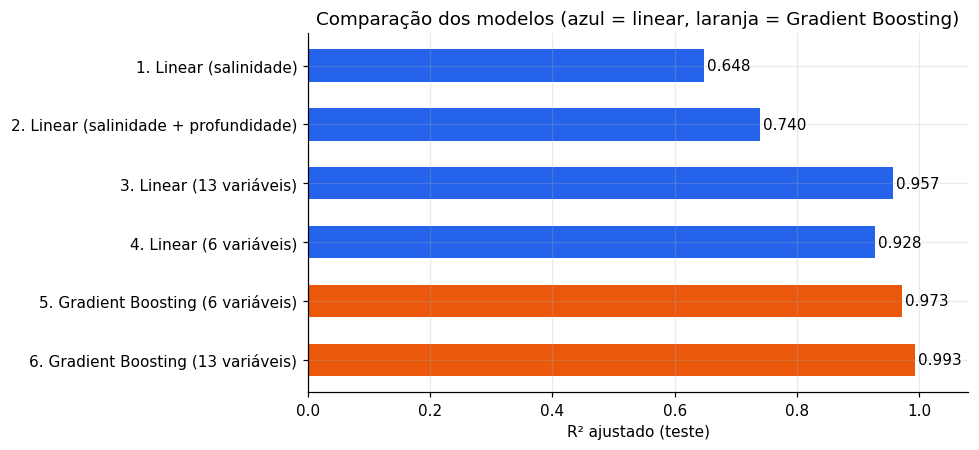

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.2))
nomes = tabela.index[::-1]
valores = tabela.loc[nomes, "R² ajustado teste"]
cores = [LARANJA if "Gradient" in n else AZUL for n in nomes]
ax.barh(nomes, valores, color=cores, height=0.55)
for i, v in enumerate(valores):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set(xlim=(0, 1.08), xlabel="R² ajustado (teste)", title="Comparação dos modelos (azul = linear, laranja = Gradient Boosting)")
plt.tight_layout(); plt.savefig(FIGURAS / "comparacao_modelos.png", bbox_inches="tight"); plt.show()

**Interpretação.**

1. **A pergunta da base:** só a salinidade explica ~65% da temperatura. Ajuda, mas não basta.
2. **As variáveis certas fazem a maior diferença:** de 0,648 (salinidade) para 0,957 (13 variáveis) no modelo linear.
3. **O modelo não linear ganha sempre:** com as mesmas variáveis, o Gradient Boosting supera a regressão linear
   (0,928 → 0,973 com 6 variáveis; 0,957 → 0,993 com 13).
4. **R² × R² ajustado:** aqui os dois são quase idênticos. Com ~17.601 medições de teste e no máximo 13 variáveis,
   a penalidade do R² ajustado é minúscula ($n$ muito maior que $p$). Ou seja: **nenhum modelo está "inflando" o R²
   com variáveis inúteis**. (No limite, o R² ajustado só pesaria se tivéssemos centenas de variáveis.)
5. **Os resultados são estáveis:** em todos os modelos a validação cruzada ficou praticamente igual ao teste, com desvio pequeno.

## 10. Teste de robustez: o modelo funciona no "futuro"?

Um R² de 0,993 é muito alto, então vale desconfiar: será que há algum vazamento escondido?

Fazemos um teste mais difícil: **treinamos só com 2005–2013 e testamos em 2014–2016**, anos que o modelo nunca viu.
Esse período inclui o **"Blob"**, uma onda de calor marinha que deixou o Pacífico anormalmente quente em 2014–2015 —
um bom teste de estresse. (A variável `Year` sai aqui, porque os anos de teste não existem no treino.)

In [24]:
SEM_ANO = [c for c in PREDITORAS if c != "Year"]
passado, futuro = dados[dados["Year"] <= 2013], dados[dados["Year"] >= 2014]

robustez = []
for nome, modelo in [("Regressão linear", LinearRegression()), ("Gradient Boosting", HistGradientBoostingRegressor(random_state=SEED))]:
    modelo.fit(passado[SEM_ANO], passado[ALVO])
    pred = modelo.predict(futuro[SEM_ANO])
    robustez.append({"modelo": nome, "R² em 2014-2016": r2_score(futuro[ALVO], pred), "MAE (°C)": mean_absolute_error(futuro[ALVO], pred)})
print(f"Treino: {len(passado):,} medições (2005-2013) | Teste: {len(futuro):,} medições (2014-2016)")
pd.DataFrame(robustez).set_index("modelo").round(3)

Treino: 67,252 medições (2005-2013) | Teste: 20,891 medições (2014-2016)


,R² em 2014-2016,MAE (°C)
modelo,,
Regressão linear,0.949,0.610
Gradient Boosting,0.980,0.363


**Interpretação.** Mesmo prevendo anos que nunca viu — e anos anormalmente quentes —, o Gradient Boosting mantém
R² de **0,980**. O resultado alto **não é vazamento**: é uma relação física real entre a temperatura e a "assinatura
química" da água (salinidade, oxigênio e nutrientes).

## 11. Diagnóstico dos resíduos

O **resíduo** é o erro de cada previsão: $e_i = y_i - \hat y_i$. Analisamos os resíduos no teste para o **Modelo 3**
(regressão linear com 13 variáveis), para verificar os pressupostos da regressão linear: resíduos com média zero,
sem padrão e com distribuição próxima da normal.

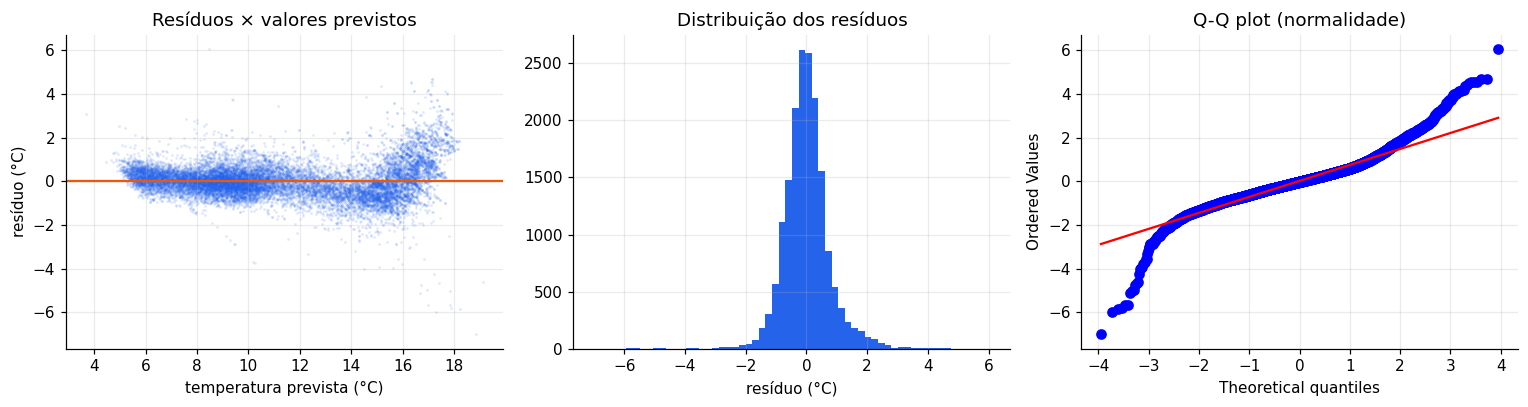

Média dos resíduos: 0.014 °C | assimetria: 0.43


In [25]:
pred_m3 = previsoes["3. Linear (13 variáveis)"]
residuos = y_teste - pred_m3

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(pred_m3, residuos, s=3, alpha=0.15, color=AZUL, linewidths=0)
axes[0].axhline(0, color=LARANJA, linewidth=1.5)
axes[0].set(title="Resíduos × valores previstos", xlabel="temperatura prevista (°C)", ylabel="resíduo (°C)")
axes[1].hist(residuos, bins=60, color=AZUL)
axes[1].set(title="Distribuição dos resíduos", xlabel="resíduo (°C)")
stats.probplot(residuos, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot (normalidade)")
plt.tight_layout(); plt.show()

print(f"Média dos resíduos: {residuos.mean():.3f} °C | assimetria: {stats.skew(residuos):.2f}")

**Interpretação.**

- A média dos resíduos é praticamente **zero**: o modelo não tem viés sistemático para cima ou para baixo.
- Até ~14 °C os erros ficam pequenos e espalhados em torno de zero. Acima disso (**água quente da superfície**)
  aparece um padrão: o modelo erra mais e de forma sistemática, e os erros "abrem" (**heterocedasticidade**).
  Na superfície a temperatura depende do sol, da estação e do vento — efeitos que uma reta não captura.
  É exatamente o que o Gradient Boosting corrige, e explica por que ele vai melhor.
- O histograma é centrado em zero, mas o Q-Q plot mostra **caudas mais pesadas** que a normal: algumas medições têm erros grandes.
  Isso não afeta as previsões nem o R², mas os p-valores da regressão devem ser lidos com cautela.

## 12. Quais variáveis o modelo final mais usa?

O Gradient Boosting não tem coeficientes, então usamos a **importância por permutação**: embaralhamos uma variável por
vez no conjunto de teste (destruindo a informação dela) e medimos **quanto o R² cai**. Quanto maior a queda, mais o
modelo depende daquela variável.

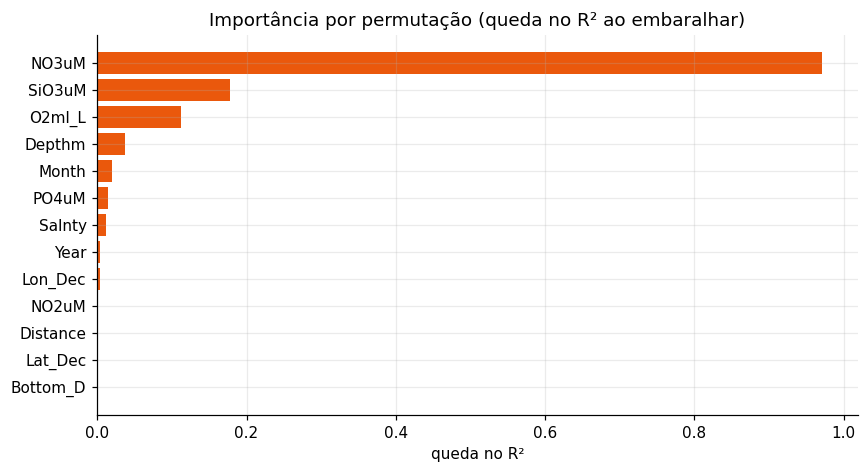

,NO3uM,SiO3uM,O2ml_L,Depthm,Month,PO4uM,Salnty,Year,Lon_Dec,NO2uM,Distance,Lat_Dec,Bottom_D
queda no R²,0.97,0.178,0.112,0.037,0.02,0.014,0.011,0.004,0.004,0.001,0.001,0.001,0.0


In [26]:
modelo_final = modelos["6. Gradient Boosting (13 variáveis)"]
perm = permutation_importance(modelo_final, X_teste[PREDITORAS], y_teste, n_repeats=5, random_state=SEED, scoring="r2")
importancia = pd.Series(perm.importances_mean, index=PREDITORAS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.barh(importancia.index, importancia.values, color=LARANJA)
ax.set(title="Importância por permutação (queda no R² ao embaralhar)", xlabel="queda no R²")
plt.tight_layout(); plt.savefig(FIGURAS / "importancia_variaveis.png", bbox_inches="tight"); plt.show()
importancia.sort_values(ascending=False).round(3).to_frame("queda no R²").T

**Interpretação.** O modelo final depende sobretudo do **nitrato** (`NO3uM`): embaralhá-lo derruba o R² em 0,97 — sem ele,
o modelo praticamente não funciona. Depois vêm o **silicato** (0,18), o **oxigênio** (0,11), a **profundidade** (0,04) e o **mês** (0,02).

A leitura física é coerente: os nutrientes e o oxigênio identificam **de qual camada do oceano** a água veio
(funda e fria × superficial e quente), e o mês ajusta a temperatura da superfície conforme a **estação do ano**.
Variáveis como latitude e profundidade do fundo têm importância quase zero no modelo final.

## 13. Modelo final

**O modelo escolhido é o Modelo 6: Gradient Boosting com 13 variáveis.**

| Item | Definição |
|---|---|
| Problema | Regressão: prever a temperatura da água (`T_degC`, em °C) |
| Algoritmo | Gradient Boosting (`HistGradientBoostingRegressor`, scikit-learn) |
| Hiperparâmetros | Padrão: 100 árvores, taxa de aprendizado 0,1, até 31 folhas por árvore, `random_state=42` |
| Variáveis | 13: salinidade, profundidade, oxigênio, 4 nutrientes, latitude, longitude, profundidade do fundo, distância da costa, mês e ano |
| Dados | 88.143 medições (2005–2016): 70.542 de treino e 17.601 de teste, divididas por estação |
| R² treino | 0,994 |
| R² validação cruzada | 0,993 ± 0,0003 |
| R² teste | **0,993** |
| R² ajustado teste | **0,993** |
| MAE / RMSE teste | 0,20 °C / 0,31 °C |

**Por que este modelo:**

1. Tem o **maior R² ajustado** dos seis — a métrica certa para comparar modelos com números diferentes de variáveis.
2. Treino, validação cruzada e teste dão valores próximos: **não há overfitting relevante**.
3. Passou no **teste de robustez temporal** (R² 0,980 em anos nunca vistos).
4. Erra em média só **0,20 °C**.

**Alternativas, se a prioridade for outra:**

| Prioridade | Modelo | R² ajustado |
|---|---|---|
| Simplicidade (menos variáveis) | 5. Gradient Boosting com 6 variáveis | 0,973 |
| Uma equação que dá para escrever | 3. Regressão linear com 13 variáveis | 0,957 |

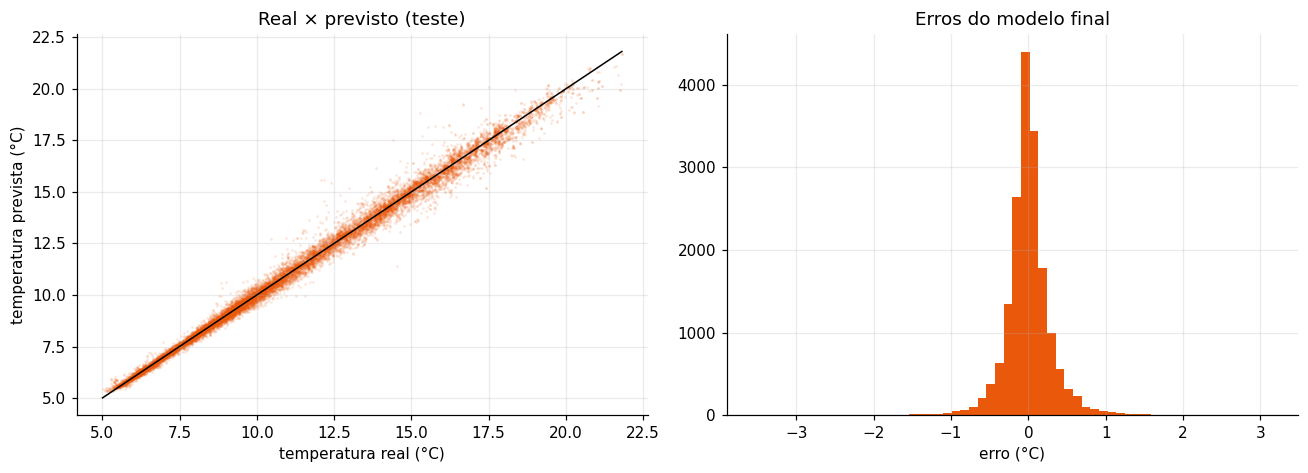

R² teste = 0.993 | R² ajustado = 0.993 | MAE = 0.20 °C
Hiperparâmetros: {'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}


In [27]:
pred_final = previsoes["6. Gradient Boosting (13 variáveis)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(y_teste, pred_final, s=3, alpha=0.15, color=LARANJA, linewidths=0)
lim = [y_teste.min(), y_teste.max()]
axes[0].plot(lim, lim, color="black", linewidth=1)
axes[0].set(title="Real × previsto (teste)", xlabel="temperatura real (°C)", ylabel="temperatura prevista (°C)")
axes[1].hist(y_teste - pred_final, bins=60, color=LARANJA)
axes[1].set(title="Erros do modelo final", xlabel="erro (°C)")
plt.tight_layout(); plt.savefig(FIGURAS / "modelo_final.png", bbox_inches="tight"); plt.show()

r = tabela.loc["6. Gradient Boosting (13 variáveis)"]
print(f"R² teste = {r['R² teste']:.3f} | R² ajustado = {r['R² ajustado teste']:.3f} | MAE = {r['MAE teste (°C)']:.2f} °C")
print("Hiperparâmetros:", {k: modelo_final.get_params()[k] for k in ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf"]})

## 14. O modelo na prática

A célula abaixo sorteia **uma medição do conjunto de teste** (que o modelo nunca viu no treino), faz a previsão
e compara com a temperatura real. Cada execução sorteia uma medição diferente.

In [28]:
i = np.random.default_rng().choice(X_teste.index)
real = y_teste.loc[i]
previsto = modelo_final.predict(X_teste.loc[[i], PREDITORAS])[0]

print(f"Estação {dados.loc[i, 'Cst_Cnt']} | {int(dados.loc[i, 'Month']):02d}/{int(dados.loc[i, 'Year'])} | lat {dados.loc[i, 'Lat_Dec']:.2f}, lon {dados.loc[i, 'Lon_Dec']:.2f}")
print(f"Profundidade: {dados.loc[i, 'Depthm']:.0f} m | salinidade: {dados.loc[i, 'Salnty']:.2f} | oxigênio: {dados.loc[i, 'O2ml_L']:.2f} ml/L | nitrato: {dados.loc[i, 'NO3uM']:.1f} µmol/L")
print(f"\nTemperatura real:     {real:.2f} °C")
print(f"Temperatura prevista: {previsto:.2f} °C")
print(f"Erro:                 {previsto - real:+.2f} °C")

Estação 32699 | 04/2011 | lat 32.00, lon -122.39
Profundidade: 30 m | salinidade: 33.39 | oxigênio: 5.78 ml/L | nitrato: 0.0 µmol/L

Temperatura real:     15.43 °C
Temperatura prevista: 15.49 °C
Erro:                 +0.06 °C


## 15. Conclusões

- **Pergunta da base:** a salinidade sozinha prevê a temperatura só parcialmente (R² ≈ 0,648).
- **Com as variáveis certas** — profundidade, oxigênio e nutrientes — o modelo linear chega a 0,957.
- **Com um modelo não linear** (Gradient Boosting), chega a **0,993**, errando em média 0,20 °C.
- **Por quê:** a temperatura do oceano não muda em linha reta com a profundidade (termoclina), e cada camada de água
  tem uma "assinatura química" (sal, oxigênio, nutrientes) que denuncia sua temperatura.
- **O resultado é confiável:** sem colunas de vazamento, com divisão por estação, validação cruzada estável e teste em anos futuros.

## 16. Limitações

- **Recorte de período:** o modelo foi treinado com 2005–2016 na costa da Califórnia; não deve ser usado para outros
  oceanos ou para décadas muito diferentes sem ser re-treinado.
- **Nutrientes precisam ser medidos:** na prática, medir nutrientes exige coleta e laboratório; o modelo é mais útil para
  **completar** dados faltantes ou checar medições suspeitas do que para substituir o termômetro.
- **Hiperparâmetros padrão:** não fizemos ajuste fino do Gradient Boosting; poderia melhorar um pouco.
- **Mês como número:** dezembro (12) e janeiro (1) ficam "longe" numericamente, embora sejam vizinhos. Para a regressão
  linear isso atrapalha; uma alternativa seria codificar o mês de forma cíclica (seno/cosseno).
- **Pressupostos da regressão linear:** os resíduos do Modelo 3 mostram padrão e caudas pesadas, então os p-valores dos
  modelos lineares devem ser lidos com cautela.